## LLM day - 9 : RAG (Retrieval Augmented Generation)

An AI **hallucination** is when a language model states something that is incorrect or completely made up, but presents it as a fact. It's essentially the AI confidently inventing information because it doesn't know the correct answer.
### Example of Hallucination

**User Query:**
"Who was the first person to walk on Mars?"

**Hallucinated LLM Response:**
"The first person to walk on Mars was cosmonaut Alexei Leonov on the Soviet Union's Ares 1 mission in 1988. He spent three hours collecting rock samples before returning safely to Earth."

This answer sounds plausible with specific details like a name, mission, and date, but it's entirely false. No human has ever walked on Mars. The AI has "hallucinated" these details by mixing up facts about missions to other celestial bodies (like the moon) and Soviet space program history.

**Fine-tuning** is the process of taking a general, pre-trained AI model and training it further on a smaller, specific dataset to make it an expert on a particular topic or task.

It's like taking a doctor who has just graduated from medical school and sending them to a specialized cardiology program. They go from having broad medical knowledge to being an expert on the heart.

### Example of Fine-tuning

1.  **Start with a General Model:** You begin with a powerful base model like Gemini, which knows about history, science, art, and many other topics.

2.  **Create a Specific Dataset:** You gather thousands of examples of your company's customer support chats. This dataset includes common customer questions and the ideal, polite, and accurate answers provided by your best support agents.

3.  **Continue Training:** You then "fine-tune" the general model by training it only on this specific customer support dataset.

**Result:**
The fine-tuned model becomes an expert at handling your company's customer support. It learns your specific product names, understands common issues, and adopts the polite and helpful tone of your brand, providing much better answers for that specific job than the general model could.

### In-Context Learning
In-Context Learning is a core capability of Large Language Models (LLMs) like GPT-3/4, Claude, and Llama, where the model learns to solve a task purely by seeing examples in the prompt—without updating its weights.

### RAG
RAG is a way to make a language model (like ChatGPT) smarter by giving it extra information at the time you ask your question.
It consists of :
1. Indexing
2. Retrieval
3. Augmentation
4. Generation

### Indexing
Indexing is the process of **preparing your knowledge base** so that it can be efficiently searched at query time. This steps consists of 4 sub-steps.

**1. Document Ingestion** - You load your source knowledge into memory.
* **Examples:**
    * PDF reports, Word documents
    * YouTube transcripts, blog pages
    * GitHub repos, internal wikis
    * SQL records, scraped webpages
* **Tools:**
    * LangChain loaders (`PyPDFLoader`, `YoutubeLoader`, `WebBaseLoader`, `GitLoader`, etc.)

---

**2. Text Chunking** - Break large documents into small, semantically meaningful chunks
* **Why chunk?**
    * LLMs have context limits (e.g., 4K-32K tokens)
    * Smaller chunks are more focused → better semantic search
* **Tools:**
    * `RecursiveCharacterTextSplitter`, `MarkdownHeaderTextSplitter`, `SemanticChunker`

---

**3. Embedding Generation** - Convert each chunk into a **dense vector** (embedding) that captures its **meaning**.
* **Why embeddings?**
    * Similar ideas land close together in vector space
    * Allows fast, fuzzy semantic search
* **Tools:**
    * `OpenAIEmbeddings`, `SentenceTransformerEmbeddings`, `InstructorEmbeddings`, etc.

---

**4. Storage in a Vector Store** - Store the vectors along with the original chunk text + metadata in a **vector database**.
* **Vector DB options:**
    * **Local:** `FAISS`, `Chroma`
    * **Cloud:** `Pinecone`, `Weaviate`, `Milvus`, `Qdrant`

### Retrieval  
Retrieval is the real-time process of finding the most relevant pieces of information from a pre-built index (created during indexing) based on the user's question.<br>
It's like asking:<br>
"From all the knowledge I have, which 3–5 chunks are most helpful to answer this query?"

### Augmentation 
Augmentation refers to the step where the retrieved documents (chunks of relevant context) are combined with the user's query to form a new, enriched prompt for the LLM.

### Generation 
Generation is the final step where a Large Language Model (LLM) uses the user's query and the retrieved & augmented context to generate a response.

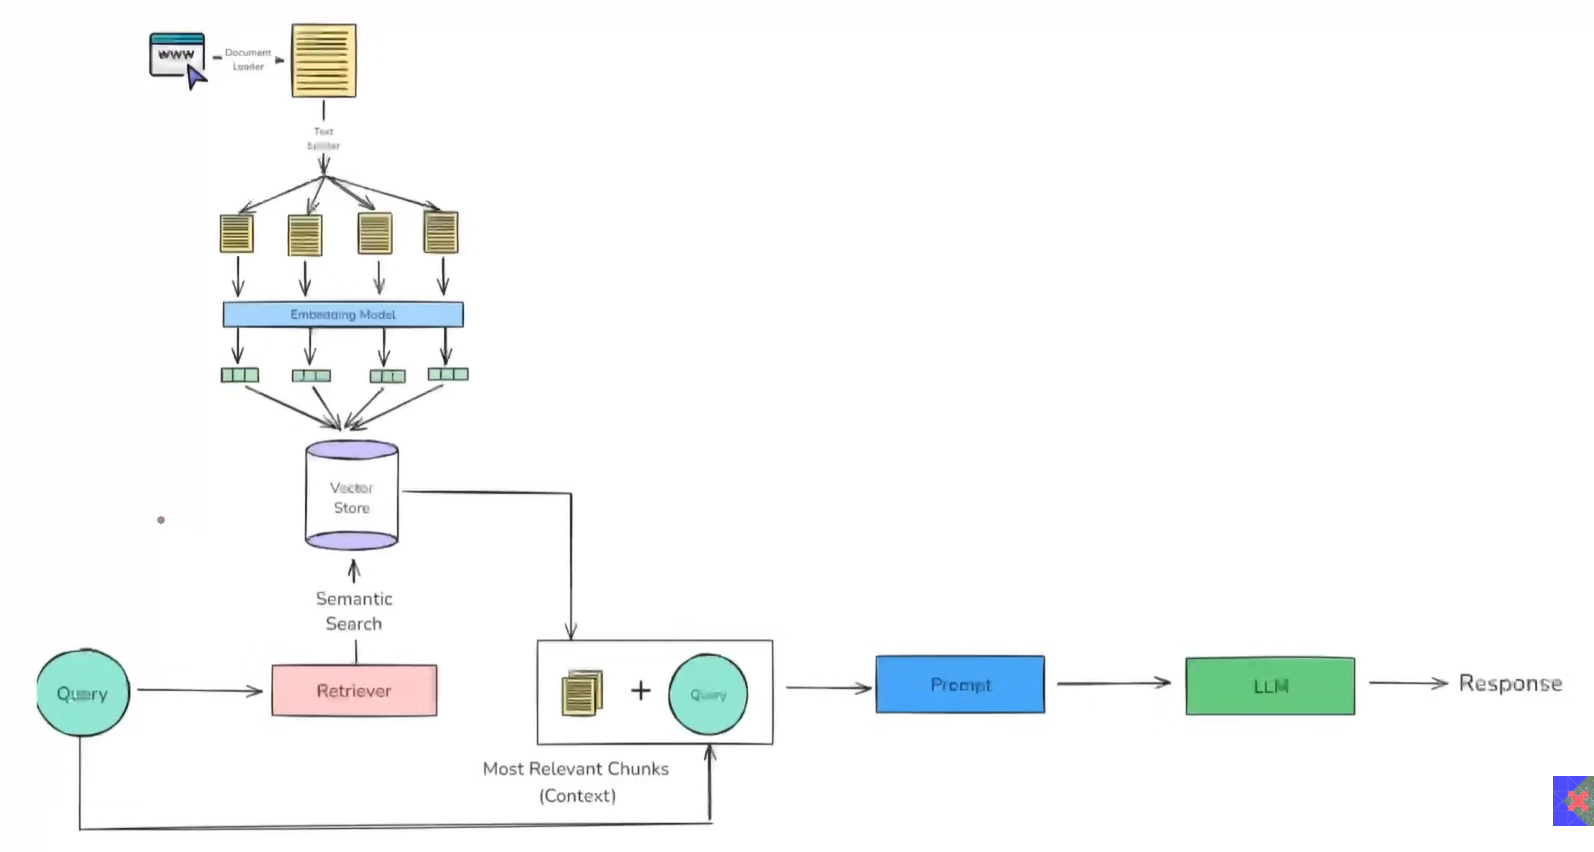